**<h1>Video Game Sales  Analysis</h1>**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("vgsales.csv")

In [5]:
df.duplicated().sum()

np.int64(1)

In [6]:
df = df.drop_duplicates()

In [7]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 16597 entries, 0 to 16597
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                16597 non-null  object 
 1   Platform            16597 non-null  object 
 2   Year                16327 non-null  float64
 3   Genre               16597 non-null  object 
 4   Publisher           16539 non-null  object 
 5   NorthAmerica_Sales  16597 non-null  float64
 6   Europe_Sales        16597 non-null  float64
 7   Japan_Sales         16597 non-null  float64
 8   Other_Sales         16597 non-null  float64
 9   Global_Sales        16597 non-null  float64
dtypes: float64(6), object(4)
memory usage: 1.4+ MB


Name                    0
Platform                0
Year                  270
Genre                   0
Publisher              58
NorthAmerica_Sales      0
Europe_Sales            0
Japan_Sales             0
Other_Sales             0
Global_Sales            0
dtype: int64

In [10]:
df['Year']=df['Year'].fillna(df['Year'].median())
df['Year']=df['Year'].astype(int)

In [13]:
df['Publisher'] = df['Publisher'].fillna(df['Publisher'].mode()[0])

In [14]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 16597 entries, 0 to 16597
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                16597 non-null  object 
 1   Platform            16597 non-null  object 
 2   Year                16597 non-null  int64  
 3   Genre               16597 non-null  object 
 4   Publisher           16597 non-null  object 
 5   NorthAmerica_Sales  16597 non-null  float64
 6   Europe_Sales        16597 non-null  float64
 7   Japan_Sales         16597 non-null  float64
 8   Other_Sales         16597 non-null  float64
 9   Global_Sales        16597 non-null  float64
dtypes: float64(5), int64(1), object(4)
memory usage: 1.4+ MB


Name                  0
Platform              0
Year                  0
Genre                 0
Publisher             0
NorthAmerica_Sales    0
Europe_Sales          0
Japan_Sales           0
Other_Sales           0
Global_Sales          0
dtype: int64

In [16]:
Top_10=df.groupby('Name')['Global_Sales'].sum().sort_values(ascending=False).head(10)
Top_10

Name
Wii Sports                        82.74
Grand Theft Auto V                55.92
Super Mario Bros.                 45.31
Tetris                            35.84
Mario Kart Wii                    35.82
Wii Sports Resort                 33.00
Pokemon Red/Pokemon Blue          31.37
Call of Duty: Black Ops           31.03
Call of Duty: Modern Warfare 3    30.83
New Super Mario Bros.             30.01
Name: Global_Sales, dtype: float64

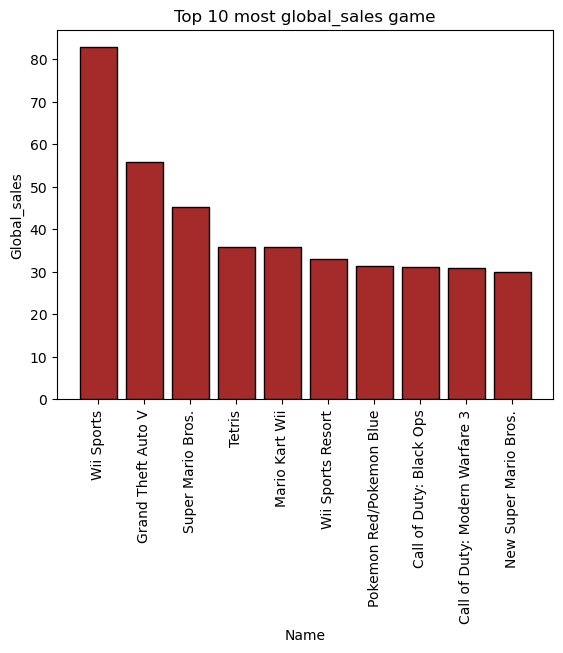

In [17]:
plt.bar(Top_10.index,Top_10.values,
        color="Brown",
        edgecolor="Black"
       )
plt.xticks(rotation=90)
plt.xlabel("Name")
plt.ylabel("Global_sales")
plt.title("Top 10 most global_sales game")
plt.show()
        

In [21]:
genre_sales=df.groupby('Genre')['Global_Sales'].sum().reset_index()
genre_sales

,Genre,Global_Sales
0,Action,1751.18
1,Adventure,239.04
2,Fighting,448.91
3,Misc,809.96
4,Platform,831.37
5,Puzzle,244.95
6,Racing,732.04
7,Role-Playing,927.37
8,Shooter,1037.35
9,Simulation,392.20


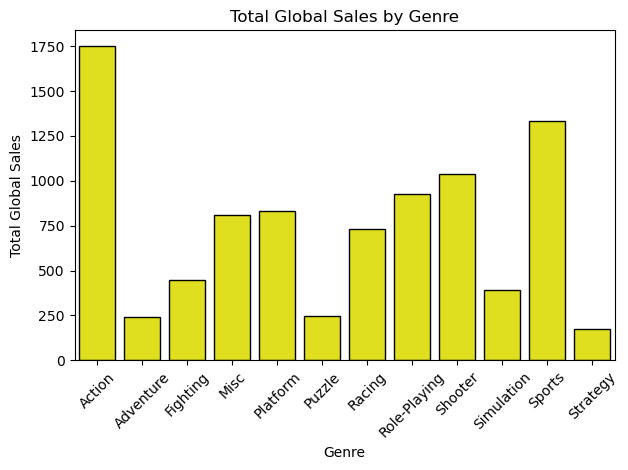

In [22]:
sns.barplot(x='Genre', y='Global_Sales', data=genre_sales,
           color="yellow",
            edgecolor="black")
        
plt.xticks(rotation=45)
plt.xlabel("Genre")
plt.ylabel("Total Global Sales")
plt.title("Total Global Sales by Genre")
plt.tight_layout()
plt.show()

In [24]:
top_selling_year=df.groupby('Year')['Name'].count().sort_values(ascending=False).head(10)
top_selling_year

Year
2007    1472
2009    1431
2008    1428
2010    1259
2011    1139
2006    1008
2005     941
2002     829
2003     775
2004     763
Name: Name, dtype: int64

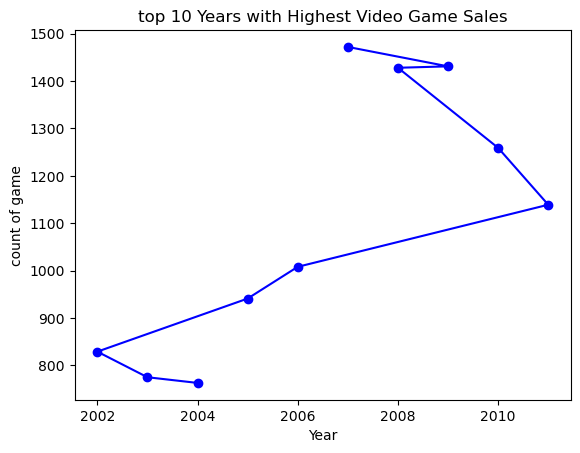

In [30]:
plt.plot(top_selling_year.index,top_selling_year.values, 
                          color="Blue", 
                          marker="o" ) 
plt.xlabel("Year") 
plt.ylabel("count of game") 
plt.title("top 10 Years with Highest Video Game Sales") 
plt.show()

In [34]:
japan_genre_sales=df.groupby('Genre')['Japan_Sales'].sum().sort_values(ascending=False).head(5)
japan_genre_sales

Genre
Role-Playing    352.31
Action          159.95
Sports          135.37
Platform        130.77
Misc            107.76
Name: Japan_Sales, dtype: float64

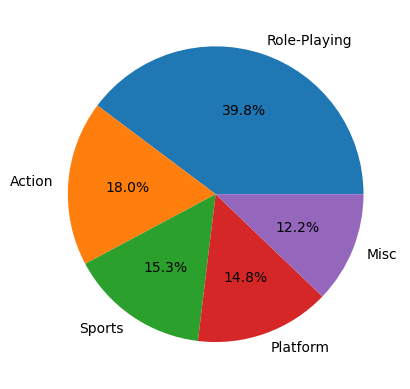

In [36]:
plt.pie(japan_genre_sales.values,
        labels=japan_genre_sales.index,
        autopct="%1.1f%%"
       )
plt.title("total contribution of genre in Japan_sales")
plt.show()
        

In [43]:
top_platform=df.groupby('Platform')['Name'].count().sort_values(ascending=False).head(10).reset_index()
top_platform

,Platform,Name
0,DS,2163
1,PS2,2161
2,PS3,1329
3,Wii,1324
4,X360,1265
5,PSP,1213
6,PS,1196
7,PC,960
8,XB,824
9,GBA,822


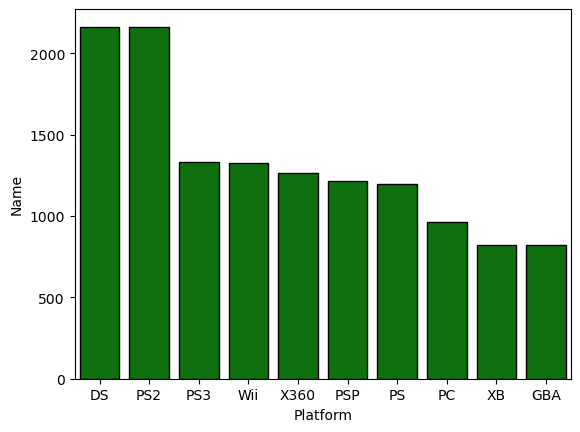

In [47]:
sns.barplot(x="Platform",y="Name", data=top_platform,
            color="Green",
            edgecolor="Black")
plt.title("platform wise top 10 game")
plt.show()

In [49]:
platform_sales = df.groupby("Platform")["Global_Sales"].sum()
top5_platforms = platform_sales.sort_values(ascending=False).head(5)
top5_platforms

Platform
PS2     1255.64
X360     979.96
PS3      957.84
Wii      926.69
DS       822.49
Name: Global_Sales, dtype: float64

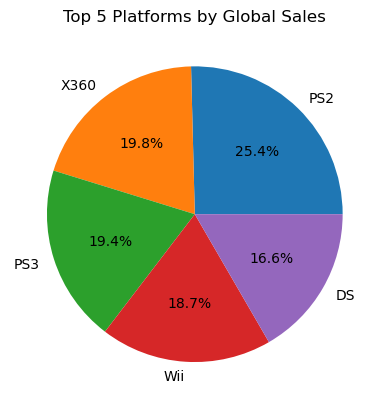

In [50]:
plt.pie(top5_platforms, labels=top5_platforms.index, 
        autopct="%1.1f%%")
plt.title("Top 5 Platforms by Global Sales")
plt.show()

In [54]:
top_publisher=df.groupby('Year')['Publisher'].count().sort_values(ascending=False).head(5)
top_publisher

Year
2007    1472
2009    1431
2008    1428
2010    1259
2011    1139
Name: Publisher, dtype: int64

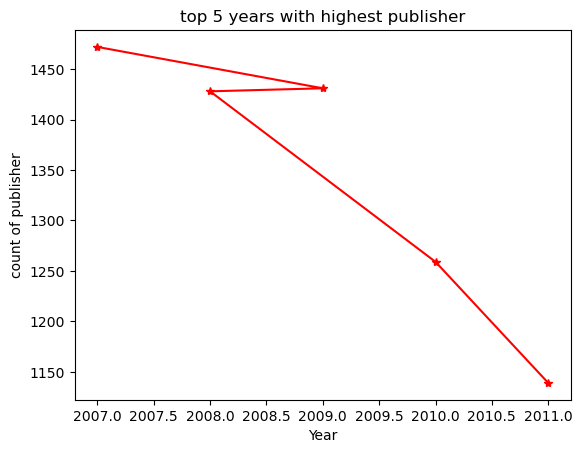

In [55]:
plt.plot(top_publisher.index,top_publisher.values,
         color="Red",
         marker="*"
        )
plt.xlabel("Year")
plt.ylabel("count of publisher")
plt.title("top 5 years with highest publisher")
plt.show()

In [60]:
top_othersales_publisher=df.groupby('Publisher')['Other_Sales'].sum().sort_values(ascending=False).head(5)
top_othersales_publisher

Publisher
Electronic Arts                130.44
Nintendo                        95.33
Sony Computer Entertainment     80.45
Activision                      75.34
Take-Two Interactive            55.24
Name: Other_Sales, dtype: float64

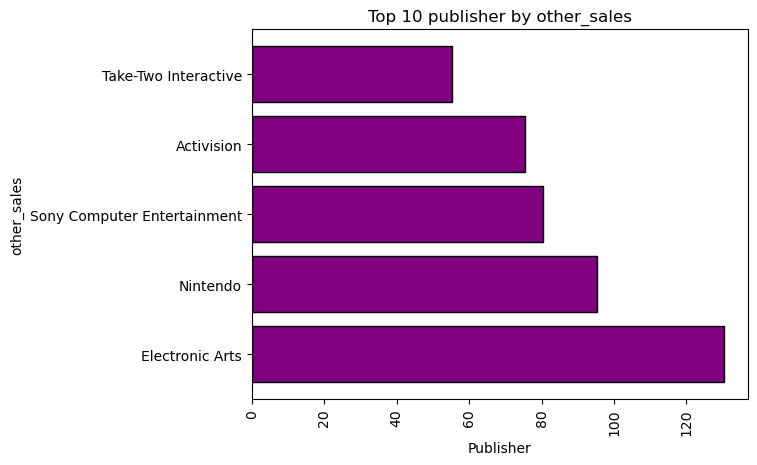

In [65]:
plt.barh(top_othersales_publisher.index,top_othersales_publisher.values,
        color="purple",
        edgecolor="black")
plt.xticks(rotation=90)
plt.xlabel("Publisher")
plt.ylabel("other_sales")
plt.title("Top 10 publisher by other_sales")
plt.show()